<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/ML_Experiment_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

In [13]:
path = kagglehub.dataset_download("uciml/iris")
print("Files in dataset folder:", os.listdir(path))

csvs = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csvs[0]))

print("Dataset shape:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'iris' dataset.
Files in dataset folder: ['Iris.csv', 'database.sqlite']
Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
# Rename columns for uniformity (original columns are already fine, skipping explicit rename)

# Encode target
X = df.drop('Species', axis=1)
y = df['Species']

# Scale features (excluding the 'Id' column)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop('Id', axis=1))

print("\nTarget Distribution:\n", y.value_counts())


Target Distribution:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


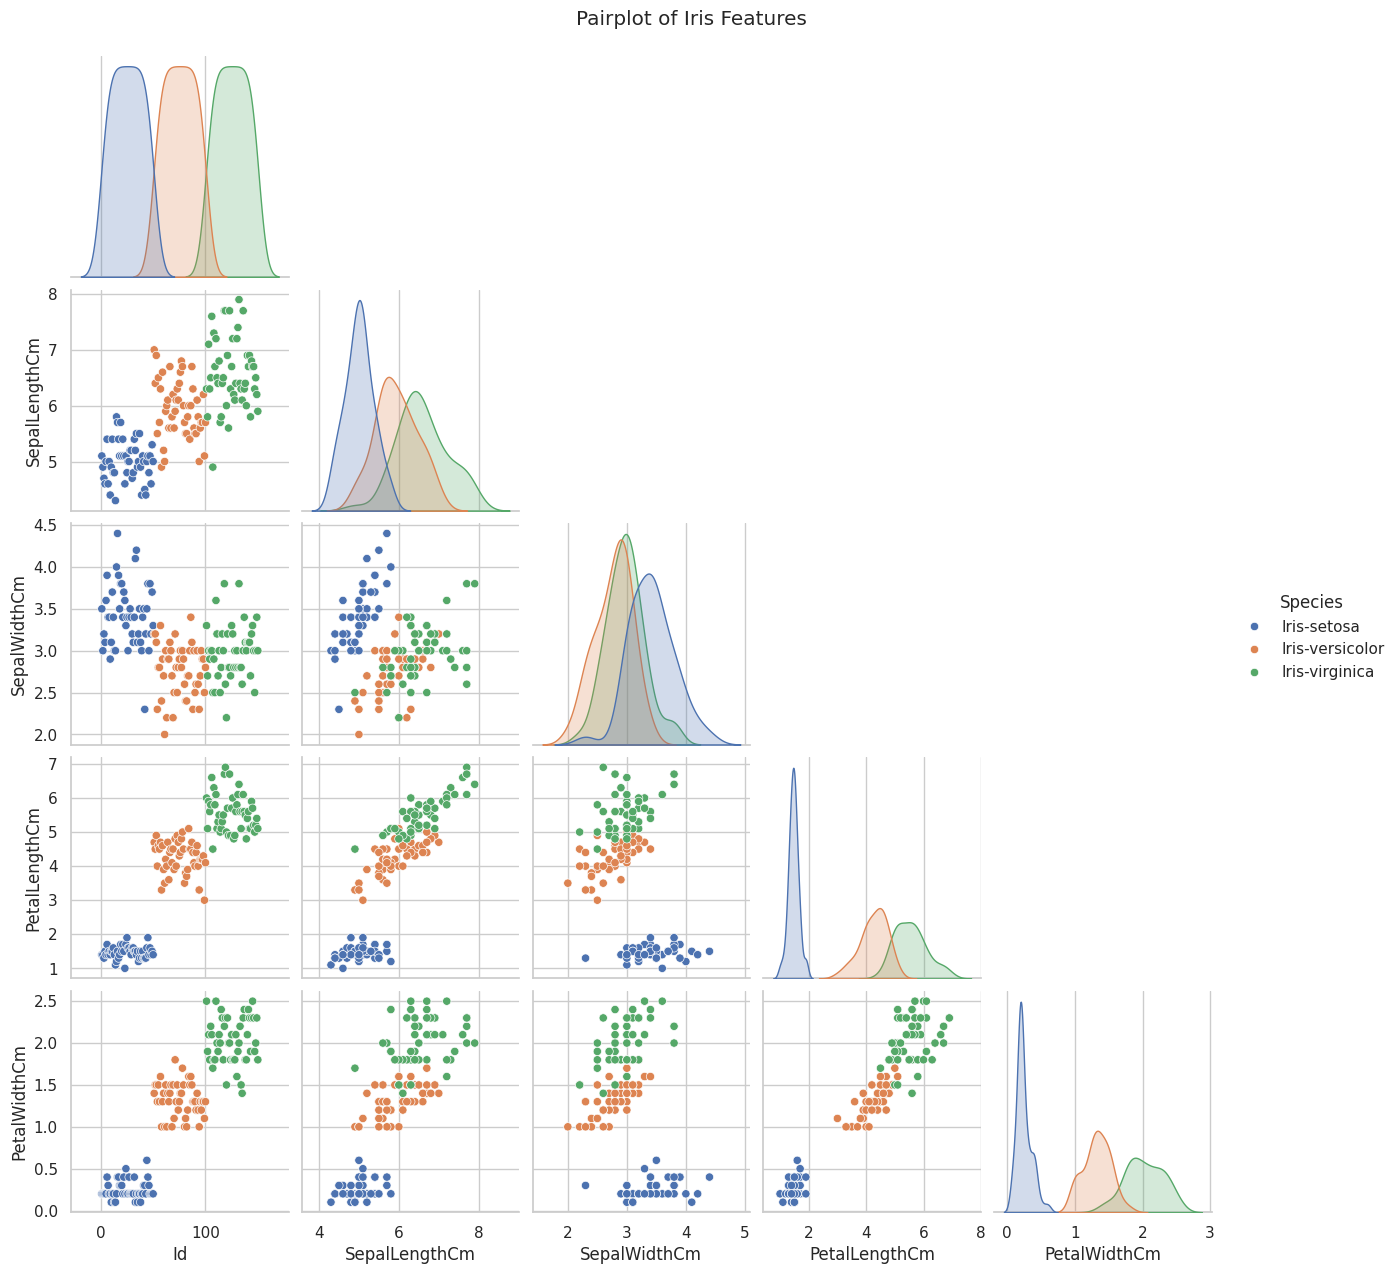

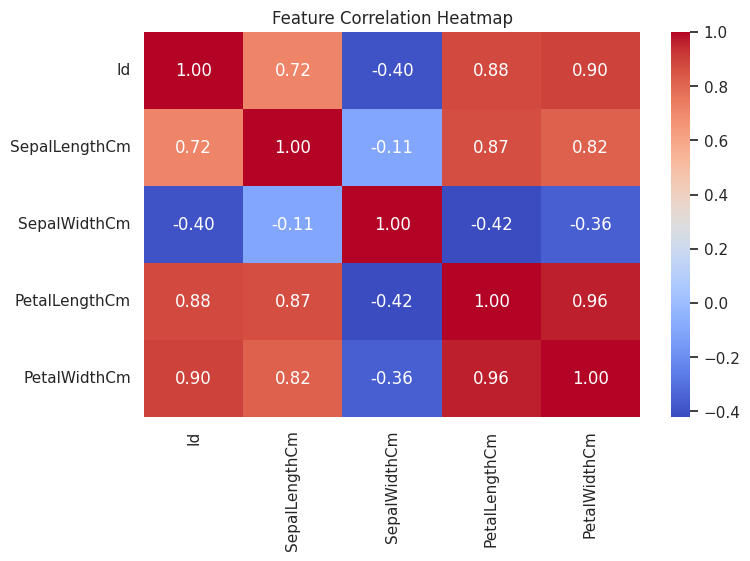

In [15]:
sns.pairplot(df, hue='Species', diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()


Explained variance ratio (LDA): [0.99147248 0.00852752]


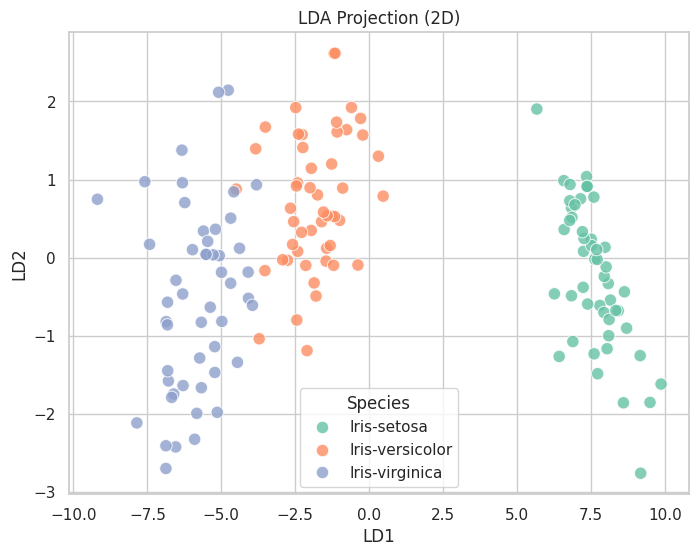

In [16]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("\nExplained variance ratio (LDA):", lda.explained_variance_ratio_)

# Plot LDA projection
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=y, palette='Set2', s=80, alpha=0.8)
plt.title("LDA Projection (2D)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend(title="Species")
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.2, random_state=42)
X_train_lda, X_test_lda, _, _ = train_test_split(X_lda, y, stratify=y, test_size=0.2, random_state=42)

clf_ori = RandomForestClassifier(n_estimators=200, random_state=42)
clf_lda = RandomForestClassifier(n_estimators=200, random_state=42)

clf_ori.fit(X_train, y_train)
clf_lda.fit(X_train_lda, y_train)

y_pred_ori = clf_ori.predict(X_test)
y_pred_lda = clf_lda.predict(X_test_lda)


Original Features:
Accuracy: 0.9
F1 (macro): 0.899749373433584

LDA Features:
Accuracy: 1.0
F1 (macro): 1.0

Classification Report (Original):
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


Classification Report (LDA):
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



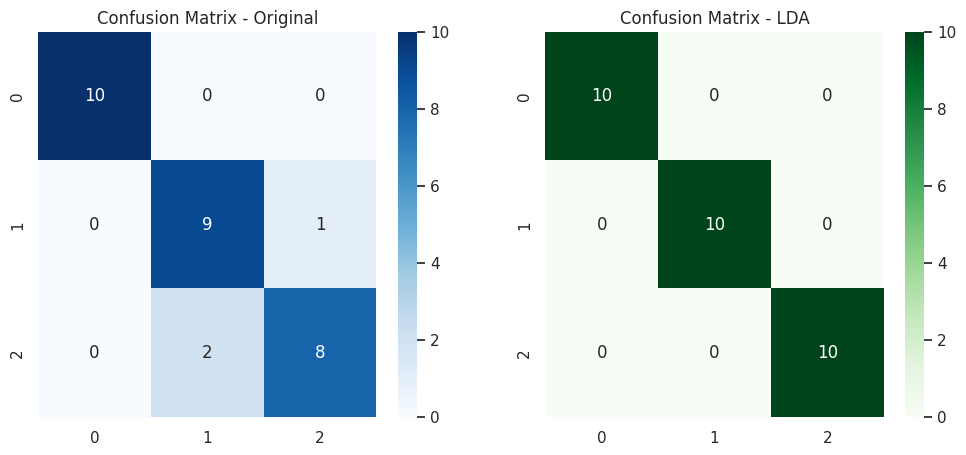

In [18]:
print("\nOriginal Features:")
print("Accuracy:", accuracy_score(y_test, y_pred_ori))
print("F1 (macro):", f1_score(y_test, y_pred_ori, average='macro'))

print("\nLDA Features:")
print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print("F1 (macro):", f1_score(y_test, y_pred_lda, average='macro'))

print("\nClassification Report (Original):\n", classification_report(y_test, y_pred_ori))
print("\nClassification Report (LDA):\n", classification_report(y_test, y_pred_lda))

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_test, y_pred_ori), annot=True, fmt='d', ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix - Original")
sns.heatmap(confusion_matrix(y_test, y_pred_lda), annot=True, fmt='d', ax=axes[1], cmap="Greens")
axes[1].set_title("Confusion Matrix - LDA")
plt.show()